# Import Libraries

In [ ]:
%load_ext autoreload
%autoreload 2
import sys
import math
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import csv
from sklearn import svm
import pandas as pd
import itertools
from itertools import zip_longest
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset, RandomSampler
from torch.optim import Adam, LBFGS
import pickle
import os
import json

current_dir = os.getcwd()
training_data_dir = os.path.join(current_dir, '../../../')
model_dir = os.path.join(current_dir, '../')
sys.path.insert(0,str(training_data_dir))
sys.path.insert(0,str(model_dir))

from training_data.simdata_mush_dirc_icc import  *
from Model.loss_func_sol import loss_fn_data,pde_loss,ic_loss,boundary_loss
from Model.train_testloop_norm import *

MPS is available
Using device: mps
MPS is available
Using device: mps
MPS is available


The spatial step is 0.0003061224489795918
The time step is 0.000330226858600583


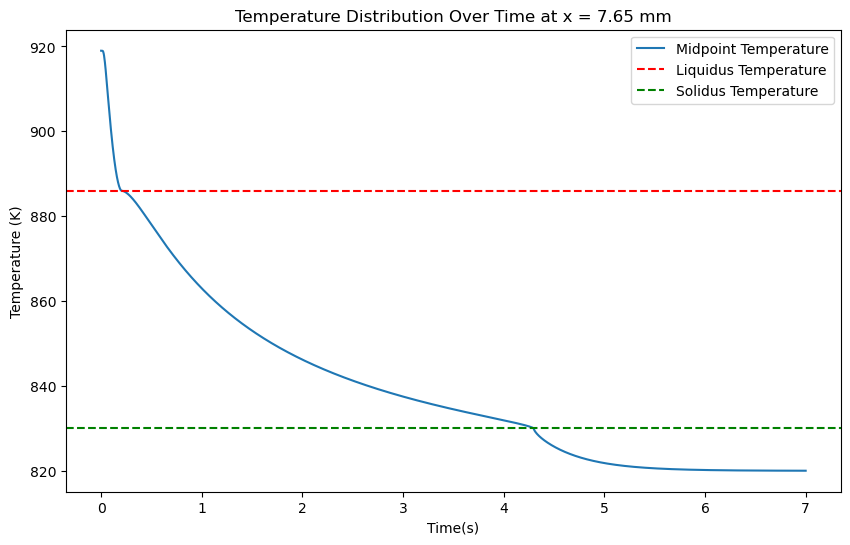

In [2]:
with open('../../../training_data/settings.json') as file:
    settings = json.load(file)
   


heat_data = HT_sim(settings)
alpha = heat_data.alpha_l
tempfield = heat_data.datagen()

heat_data.plot_temp(25)
dt = heat_data.dt
dx = heat_data.dx
# print(heat_data.dx)
# print(dt)
with open('../../../training_data/settings.json') as file:
    props = json.load(file)

In [3]:
if torch.backends.mps.is_available():
    print("MPS is available")
    device = torch.device('mps')
else:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('Using device:', device)

MPS is available


In [4]:
num_steps = tempfield.shape[0]
numpoints = tempfield.shape[1] 

pde_pts= props["pde_pts"]
ic_pts = props["ic_pts"]
bc_pts = props["bc_pts"]


length = props['length']
time_end = props['time_end']

x_c = 1/length
k_max = props['k_l']
rho_max = props['rho_s']
cp_max = props['cp_l']
alpha_max = k_max / (rho_max * cp_max)
t_c = alpha_max/(length**2)
temp_c = props['temp_init']

inp_data = fdd(15e-3, time_end, numpoints, num_steps)


def scale2(x,x_c,t_c):
    scaled_x = x.copy()
    scaled_x[:,0] = x[:,0] * x_c
    scaled_x[:,1] = x[:,1] * t_c
    return scaled_x

inp_data2 = scale2(inp_data,x_c,t_c)


input_t = torch.tensor(inp_data2).float().to(device)
# bc_ldata2 = scale2(bc_ldata,x_c,t_c)
# bc_rdata2 = scale2(bc_rdata,x_c,t_c)

In [5]:
temp_data = tempfield.flatten()
temp_t = torch.tensor(temp_data).float().to(device)
temp_t = temp_t.view(-1,1)

# temp_init_s= temp_scaler(919.0, temp_init, t_surr)
# temp_init = scaler(temp_init,500.0,919.0)
temp_init = props['temp_init']  #  K -Initial Temperature (919 c) AL 380
temp_init_t = torch.tensor(temp_init).float().to(device)
T_L = props['T_L']                   #  K -Liquidus Temperature (615 c) AL 380
# T_L_s = scaler(T_L,temp_init, t_surr)                     #  K -Liquidus Temperature (615 c) AL 380
# T_L = scaler(T_L,500.0,919.0)
T_S = props['T_S']                   #  K -Solidus Temperature (615 c) AL 380
# T_S_s = scaler(T_S,temp_init, t_surr)                     #  K -Solidus Temperature (615 c) AL 380
# T_S = scaler(T_S,500.0,919.0)                     #  K -Solidus Temperature (615 c) AL 380
# t_surr_s = temp_scaler(t_surr, temp_init, t_surr)
# t_surr = scaler(t_surr,500.0,919.0)
t_surr = props['t_surr']                   #  K -Surrounding Temperature (500 c) AL 380
T_lt = torch.tensor(T_L).float().to(device)    # Liquidus Temperature tensor
T_st = torch.tensor(T_S).float().to(device)    # Solidus Temperature tensor
t_surrt = torch.tensor(t_surr).float().to(device)   # Surrounding Temperature tensor

temp_var = {"T_st":T_st,"T_lt":T_lt,"t_surrt":t_surrt,"temp_init_t":temp_init_t}


# Fetch the data and models

In [6]:
job_id = 6696000
# Load the loss data from Output
file_path_tr = f"job_{job_id}/train-loss.pkl"

file_path_tt = f"job_{job_id}/test-loss.pkl"


In [7]:
from Model.model import PINN



In [8]:

import io
# Load train and test losses
# train_loss = load_pickle(file_path_tr)
# with open(file_path_tr, 'rb') as f:
#     train_loss = pickle.load(f)

with open(file_path_tr, 'rb') as f:
    train_loss = pickle.load(f)

with open(file_path_tt, 'rb') as f:
    test_loss = pickle.load(f)

loss_train = train_loss
loss_test = test_loss
# print(f"Train loss loaded on {device}: {type(train_loss)}")
# print(f"Test loss loaded on {device}: {type(test_loss)}")

# Load the Trained Model
num_neurons = 80
num_layers = 5
model = PINN(2, num_neurons, 1, num_layers-1).to(device)
model_location = f"job_{job_id}/best-model.pth"
model.load_state_dict(torch.load(model_location, map_location =device,weights_only=False))




<All keys matched successfully>

# visualise train test Loss

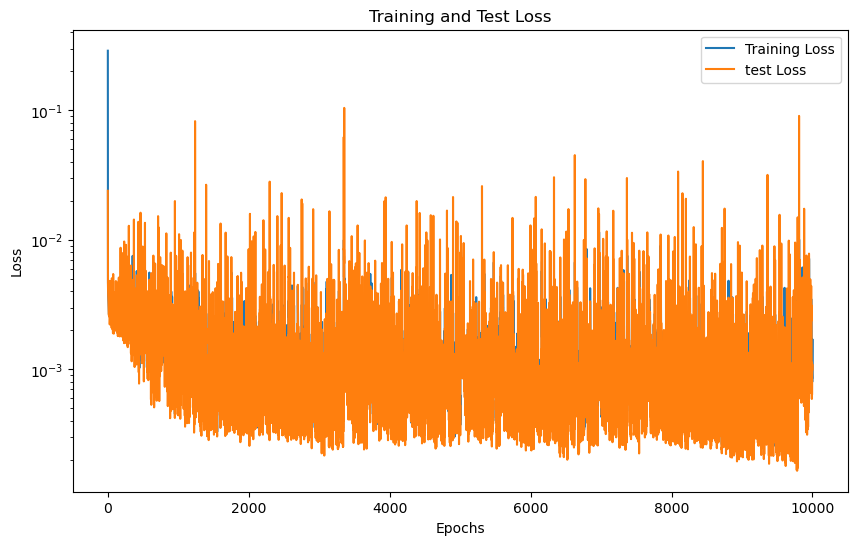

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(loss_train["train-loss"], label='Training Loss')
plt.plot(loss_test["test-loss"], label='test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Training and Test Loss')
plt.legend()
plt.show()

# Visualise PDE losses

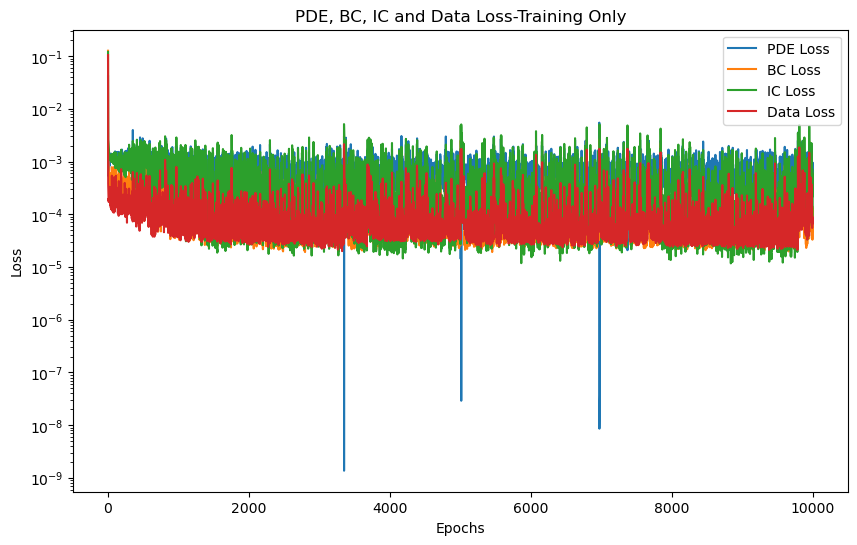

In [10]:
pde_losses = np.array(loss_train["pde-loss"])
bc_losses = np.array(loss_train["bc-loss"])
ic_losses = np.array(loss_train["ic-loss"])

data_losses = np.array(loss_train["data-loss"])

plt.figure(figsize=(10, 6))
plt.plot(pde_losses, label='PDE Loss')
plt.plot(bc_losses, label='BC Loss')
plt.plot(ic_losses, label='IC Loss')
plt.plot(data_losses, label='Data Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('PDE, BC, IC and Data Loss-Training Only')
plt.legend()
plt.show()



# Visualise results at the left, right and centre

0.9675599 0.83057797
 Temp Scaling needed and initiated


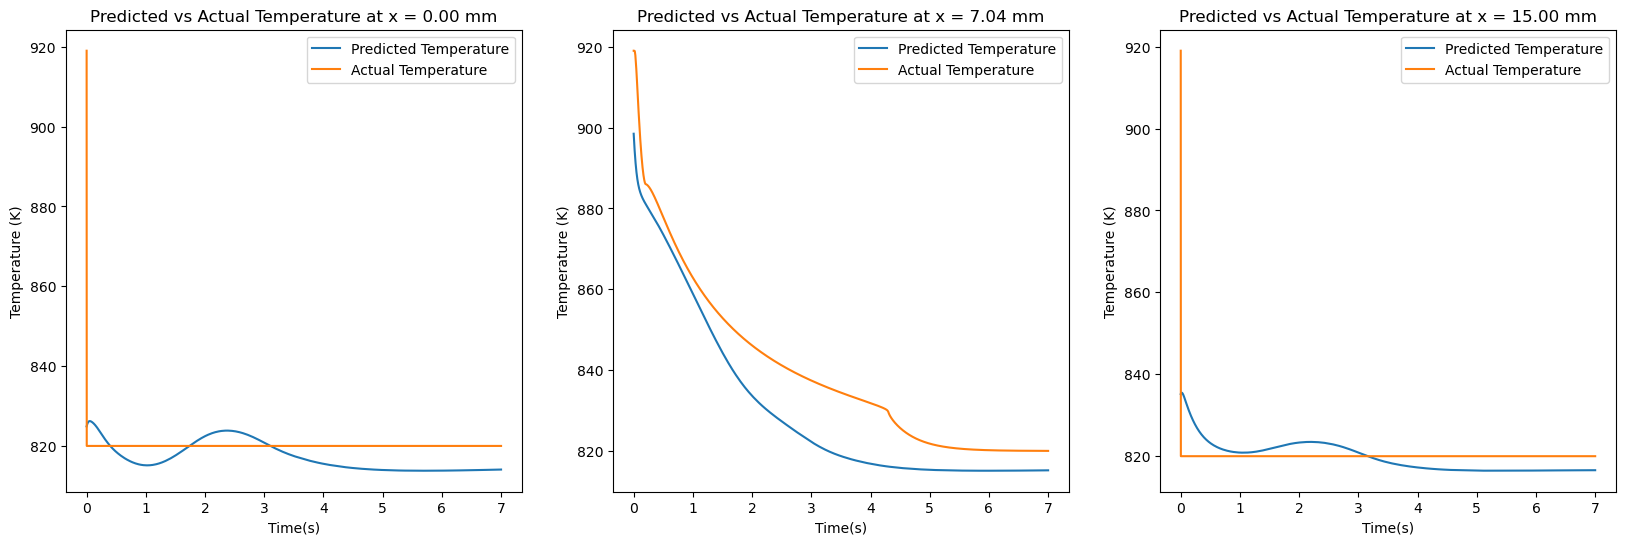

In [11]:
inp_data = input_t


temp_nn = model(inp_data[:,0].unsqueeze(1), inp_data[:,1].unsqueeze(1)).cpu().detach().numpy() # Get the predictions from the model

dx = heat_data.dx
time_end = time_end
print(np.max(temp_nn), np.min(temp_nn))
def scaler_op(temp_nn, temp_init, t_surr):
    if np.max(temp_nn) <= 1.0 :
        print(" Temp Scaling needed and initiated")
        temp_nn = temp_nn * (temp_init - t_surr)   + t_surr # Scale the predictions
    else:
        print("No scaling needed")
    return temp_nn
# def invscaler(temp_nn, temp_init, t_surr):
#     temp_nn = ((temp_nn * (temp_init - t_surr))) + t_surr
#     return temp_nn

temp_nn = scaler_op(temp_nn,temp_init,t_surr) # Inverse transform the predictions

temp_d= temp_data.reshape(num_steps, numpoints) # Reshape the actual temperature data to a 2D array

temp_nn_t = temp_nn.reshape(num_steps, numpoints) # Reshape the predictions to a 2D array

time_ss= np.linspace(0, time_end, num_steps)
left , idx, right = 0, 24,50

fig = plt.figure(figsize=(20, 6))
ax1,ax2,ax3 = fig.subplots(1,3)
ax1.plot(time_ss, temp_nn_t[:,left], label='Predicted Temperature')
ax1.plot(time_ss, temp_d[:,left], label='Actual Temperature') 
ax1.set_xlabel('Time(s)')
ax1.set_ylabel('Temperature (K)')
ax1.set_title(f'Predicted vs Actual Temperature at x = {(left)*dx*1000:.2f} mm')
ax1.legend()

ax2.plot(time_ss, temp_nn_t[:,idx-1], label='Predicted Temperature')
ax2.plot(time_ss, temp_d[:,idx-1], label='Actual Temperature')
ax2.set_xlabel('Time(s)')
ax2.set_ylabel('Temperature (K)')
ax2.set_title(f'Predicted vs Actual Temperature at x = {(idx-1)*dx*1000:.2f} mm')
ax2.legend()

ax3.plot(time_ss, temp_nn_t[:,right-1], label='Predicted Temperature')
ax3.plot(time_ss, temp_d[:,right-1], label='Actual Temperature')
ax3.set_xlabel('Time(s)')
ax3.set_ylabel('Temperature (K)')
ax3.set_title(f'Predicted vs Actual Temperature at x = {(right-1)*dx*1000:.2f} mm')
ax3.legend()
plt.show()



# Visualsie IC field

No scaling needed for time
0.85724026 0.8484687
No scaling needed


Text(0.5, 1.0, 'Predicted Temperature Distribution along initial condition')

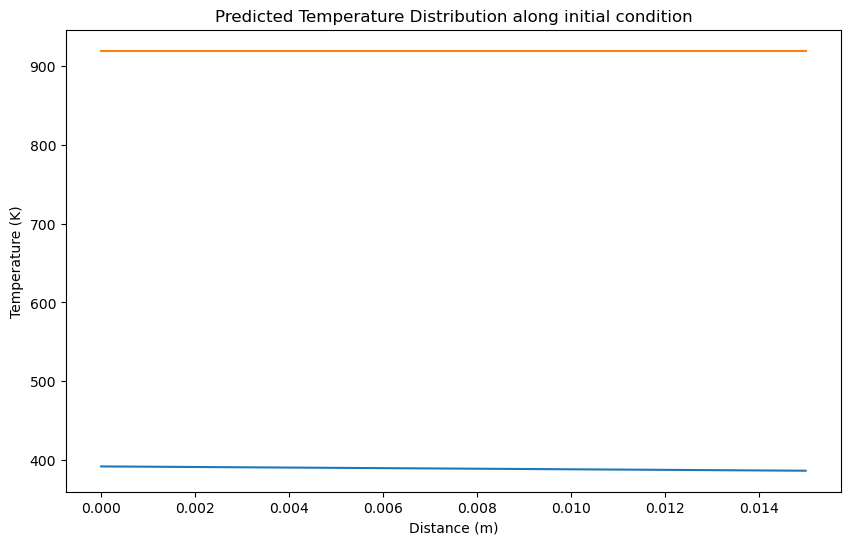

In [12]:
x = np.linspace(0, length, 50)
t = np.zeros_like(x)
alpha_max = props["k_l"] / (props["rho_s"] * props["cp_l"])  # Maximum thermal diffusivity
t_c = alpha_max/(length**2)
def scaler_inp(x,t,length, time_end):
    if np.max(x) > length or np.min(x) < 0.0 or np.max(t) > time_end or np.min(t) < 0.0:
            print("Scaling needed and initiated")
            x = x * length;
            t = t* t_c
    else:
        print("No scaling needed for time")
            
    return x, t
x,t = scaler_inp(x, t, length, time_end)

x = torch.tensor(x).float().to(device)
t = torch.tensor(t).float().to(device)
temp_pred = model(x.unsqueeze(1), t.unsqueeze(1)).cpu().detach().numpy()
print(np.max(temp_pred), np.min(temp_pred))

Act_temp_ini = tempfield[0,:]  # Get the actual temperature at the initial condition

Act_temp_r = scaler_op(Act_temp_ini,temp_init,t_surr)   # Actual temperature at initial condition

temp_pred_r = invscaler(temp_pred, temp_init, t_surr) # Inverse transform the predictions
plt.figure(figsize=(10, 6))
plt.plot(x.cpu().detach().numpy(), temp_pred_r, label='Predicted Temperature')
plt.plot(x.cpu().detach().numpy(), Act_temp_r, label='Actual Temperature')
plt.xlabel('Distance (m)')
plt.ylabel('Temperature (K)')
plt.title('Predicted Temperature Distribution along initial condition')
#end


# Visualise Field of the results

No scaling needed
(21199, 50)
 Temp Scaling needed and initiated
(1059950, 1)


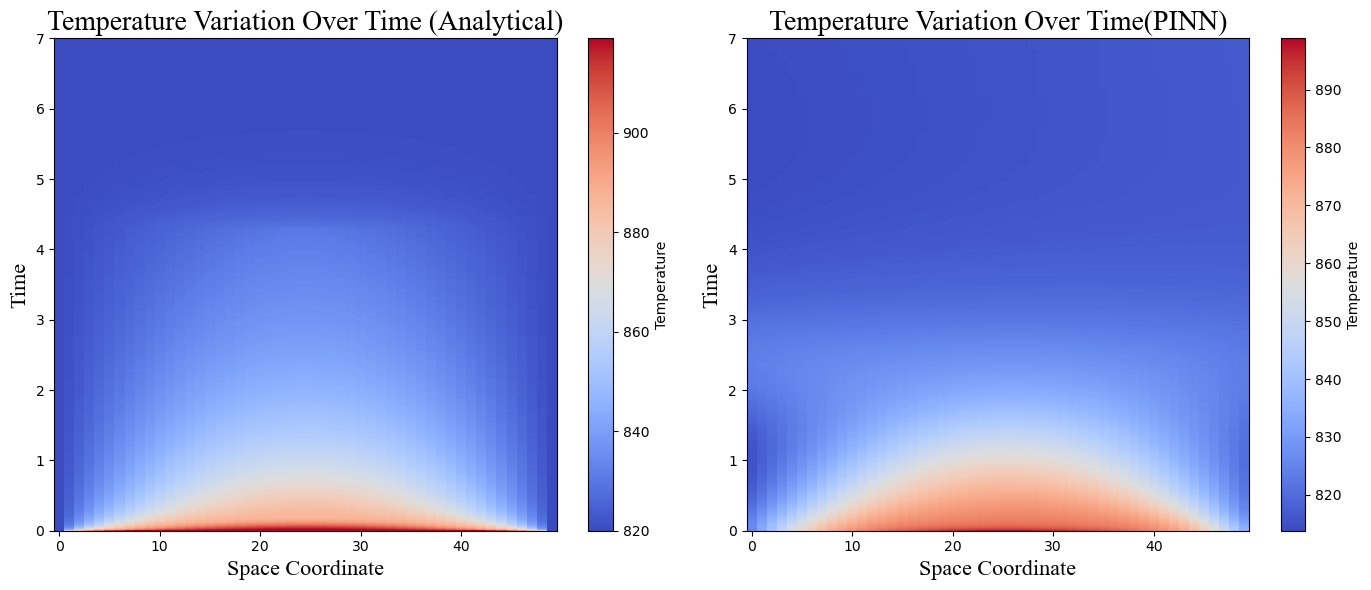

In [13]:

Act_temp = temp_data

Act_temp = scaler_op(Act_temp, temp_init, t_surr)  # Scale the actual temperature data

Act_temp = Act_temp.reshape(num_steps, numpoints)
print(Act_temp.shape)

input_pred = input_t
temp_nn = model(input_pred[:,0].unsqueeze(1), input_pred[:,1].unsqueeze(1)).cpu().detach().numpy()

temp_nn_r  = scaler_op(temp_nn, temp_init, t_surr) # Inverse transform the predictions
temp_nn_r = temp_nn_r.reshape(num_steps, numpoints)

print(temp_nn.shape)
dt = dt
space_coord, time_coord = np.meshgrid(np.arange(Act_temp.shape[1]), np.arange(Act_temp.shape[0]))
time_coord = time_coord * dt

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot the temperature history on the left subplot
im1 = ax1.pcolormesh(space_coord, time_coord, Act_temp, cmap='coolwarm')
ax1.set_xlabel('Space Coordinate', fontname='Times New Roman', fontsize=16)
ax1.set_ylabel('Time',fontname='Times New Roman', fontsize=16)
ax1.set_title('Temperature Variation Over Time (Analytical)',fontname='Times New Roman', fontsize=20)
fig.colorbar(im1, ax=ax1, label='Temperature')

im2 = ax2.pcolormesh(space_coord, time_coord, temp_nn_r, cmap='coolwarm')
ax2.set_xlabel('Space Coordinate', fontname='Times New Roman', fontsize=16)
ax2.set_ylabel('Time',fontname='Times New Roman', fontsize=16)
ax2.set_title('Temperature Variation Over Time(PINN)',fontname='Times New Roman', fontsize=20)
fig.colorbar(im2, ax=ax2, label='Temperature')

plt.tight_layout()

plt.show()



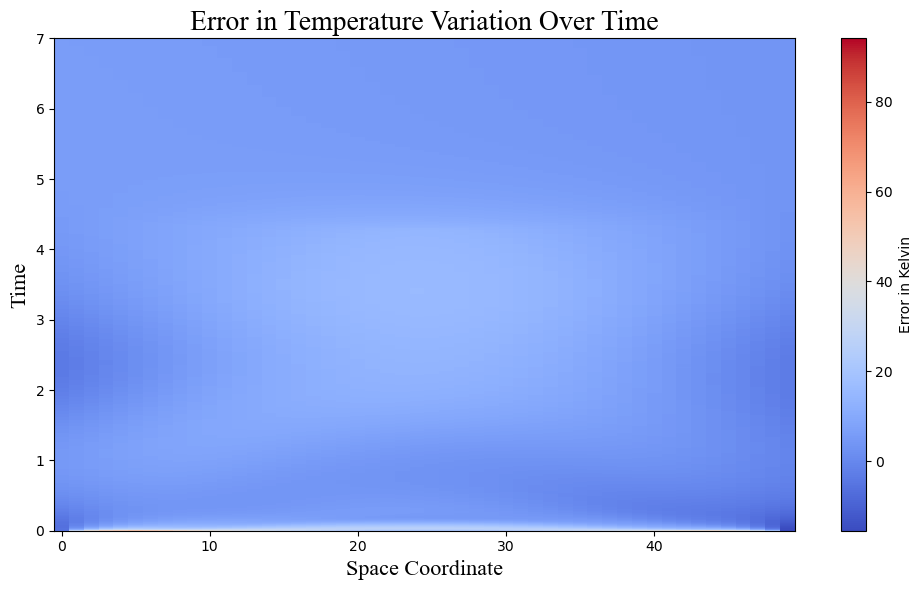

In [14]:
# Plot Error Graph

error = Act_temp - temp_nn_r

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.pcolormesh(space_coord, time_coord, error, cmap='coolwarm')
ax.set_xlabel('Space Coordinate', fontname='Times New Roman', fontsize=16)
ax.set_ylabel('Time',fontname='Times New Roman', fontsize=16)
ax.set_title('Error in Temperature Variation Over Time',fontname='Times New Roman', fontsize=20)
fig.colorbar(im, ax=ax, label='Error in Kelvin')
plt.tight_layout()
plt.show()